# Prediction of Student Academic Performance Based on Demographic, Socioeconomic, and Behavioral Factors
##### Date: May 8, 2026
##### Collaborators: Sophia Li, Tibeb Mekonen, Simone Robinson, Surabhi Singh 
##### Contributions 
| Name     | Tasks          
|----------|-----------
| Sophia   |Writeup of conclusion 
| Tibeb    | Introduction and writeup of the data curation 
| Simone   | Machine Learning Model code and writeup
| Surabhi  | Formatting of the overall markdown file, data pre-processing codem EDA analysis writeup (code was written for checkpoint 2 by Sophia, Tibeb, Simone)  



### Table of Contents 
1. Introduction
2. Data Curation and Pre-Processing
3. Exploratory Data Analysis and Summary Statistics
4. Primary Analysis using Machine Learning Algorithm
5. Visualization and Result Analysis
6. Insights and Conclusions


### 1. Introduction
A variety of demographic, socioeconomic, and educational factors influence student academic
performance. In this project, we analyze the “Students' Performance in Exams” dataset from
Kaggle to explore how variables such as race/ethnicity, parental level of education, lunch plan
status, and test preparation completion relate to student exam scores in math, reading, and
writing. Initially, our group planned to use the NHANES dataset, but due to its complexity and
extensive preprocessing requirements, we transitioned to a more focused educational dataset
that better matched the scope of our analysis
Using exploratory data analysis, hypothesis testing, and machine learning models, we
investigate several research questions related to academic achievement. We specifically looked
at whether demographic and socioeconomic variables have significant effects on student
performance and whether these factors can be used to predict exam scores. Through statistical
tests and predictive modeling, this project aims to better understand both the relationships and
limitations of using demographic data to explain educational outcomes.

### 2. Data Curation and Pre-Processing
The data being used in this project is the students' performance in Exams that came from
Kaggle. The dataset contains demographic, socioeconomic, and educational information for
1000 students alongside their corresponding exam scores in math, reading, and writing. There
are variables included, such as level of education, lunch plan status, and completion status of
test prep courses. These variables were selected because they help explain different trends and
patterns within a student's academic performance.

Initially, our group planned to use the NHANes dataset due to its extensive collection of health
and demographic information, but the dataset required combining multiple sub-datasets and
converting different XPT files into CSV, and processing thousands of variables, making it overly
complex for the scope of the project. As a result, we moved on and used the Students
Performance dataset since it was more organized, easier to preprocess, and directly related to
educational outcomes.

We first imported the DataFrame using read
_
csv(). After loading the data, the column names
were standardized by converting all letters to lowercase and replacing spaces with underscores.
This helps with readability and makes the column names easier to reference when analyzing the
data and creating data. There were also several columns remanded to provide clear
descriptions, such as: race/ethnicity, which was renamed to race, lunch was renamed to
lunch
_plan, and test
_preparation
_
course was renamed test
_prep_
course.

The next part of processing was checking the dataframe for missing values using
df.isnull().sum(). No missing values were found in any column, meaning additional cleaning was
not necessary. Next, we looked over data types to make sure variables were stored properly.
The demographic and categorical variables (gender, race, parental
_
level
_
of
_
education,
lunch
_plan, and test
_prep_
status) were converted from object types to categorical data types.
This conversion improves organization, reduces memory usage, and prepares the dataset for
statistical testing and machine learning preprocessing methods such as one-hot encoding. The
numerical exam score columns (math
_
score, reading_
score, and writing_
score) were already
stored as integer values and therefore required no additional modification.
After all this processing and cleaning, the data was ready for analysis, hypothesis testing, and
machine learning modeling.

##### Download the necessary tools/libraries

In [454]:
# Confirm that the packages will import into your selected kernel
import sys

!{sys.executable} -m pip install pandas numpy seaborn matplotlib scipy statsmodels scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip3.12 install --upgrade pip


In [455]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

##### Data Pre-Processing

In [456]:
# Load and view the dataset
df = pd.read_csv("../data/StudentsPerformance.csv")
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [457]:
# Make column names into one string
df.columns = df.columns.str.lower().str.replace(" ", "_")


In [458]:
# Rename some columns with a better description
df = df.rename(columns = {
    "race/ethnicity": "race",
    "lunch": "lunch_plan",
    "test_preparation_course": "test_prep_status"
})
df.head()


,gender,race,parental_level_of_education,lunch_plan,test_prep_status,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [459]:
# Checking for any missing values. None, so we are good!
df.isnull().sum()


gender                         0
race                           0
parental_level_of_education    0
lunch_plan                     0
test_prep_status               0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [460]:
# Check column data types
df.dtypes


gender                           str
race                             str
parental_level_of_education      str
lunch_plan                       str
test_prep_status                 str
math_score                     int64
reading_score                  int64
writing_score                  int64
dtype: object

In [461]:

# The scores are good already since they are integers. We need to make the first five columns into categorical data types, though.
categorical_columns = [
    "gender", "race", "parental_level_of_education", 
    "lunch_plan", "test_prep_status"
]

for col in categorical_columns:
    df[col] = df[col].astype("category")

df.dtypes

gender                         category
race                           category
parental_level_of_education    category
lunch_plan                     category
test_prep_status               category
math_score                        int64
reading_score                     int64
writing_score                     int64
dtype: object

### 3. Exploratory Data Analysis and Summary Statistics

Before building any machine learning models, we first should understand our dataset better. We must consider the patterns within the dataset. Exploratory Data Analysis (EDA) is able to help us identify relationships between variables and form hypotheses among the data to help us better understand how to model our machine learning algorithm.

Our dataset "Student Performance in EXams" form Kaggle contains 1,000 stendent records with features including gender, race, parental level of education, lunch_plan, test prep course status, math exam score, reading exam score, writing exam score.

From this content, we aim to analyze three main questions:

##### **Question 1: Does race/ethnicity group affect math scores?**

Race disparities have the potential to affect student educational outcomes and is a commonly researched topic. We aim to better understand if in this dataset we can see any sort of patterns that show that race affects the way a student performs on exams. Here is an article that details the racial and ethnic achievement gaps in education if you are interested in learning more about this complex topic. https://cepa.stanford.edu/educational-opportunity-monitoring-project/achievement-gaps/race/

The way we analyzed this qustion was by using a one-way ANOVA with TUKEY HSD post-hoc test. This is because we are comparing the means of a continuous variable (math exma score) across multiple groups (more than two) of people (racial groups). We use the ANOVA first to deem significance, then if significant, a Tukey's HSD post-hoc test can be used to identify which particular pairs are truly significant. 

- **H₀ (Null):** The mean math score is the same across all race/ethnicity groups.
- **Hₐ (Alternative):** At least one group has a significantly different mean math score.
- **Significance level:** α = 0.05



In [462]:
import pandas as pd
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt


groups = [group["math_score"].values for name, group in df.groupby("race")]
f_stat, p_value = f_oneway(*groups)

print("ANOVA (scipy)")
print("F-statistic:", f_stat)
print("p-value:", p_value)

ANOVA (scipy)
F-statistic: 14.593885166332637
p-value: 1.373219403036372e-11


From the ANOVA test, an F-statistic of 14.59 and p-value of  1.37 × 10⁻¹¹ was received, which is far below our α = 0.05 threshold. Therefore, we **reject the null hypothesis**, meaning that race/ethnicity group do have statistically significant effect on math scores. Now, that we know that there is a significant difference between these factors, we use the Tukey's HSD post-hoc test to see exactly which groups have a statistical difference between each other.

In [463]:
tukey = pairwise_tukeyhsd(
    endog=df["math_score"],
    groups=df["race"],
    alpha=0.05
)

print("\nTukey HSD Results:")
print(tukey)


Tukey HSD Results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
group A group B   1.8234 0.8724   -3.36  7.0068  False
group A group C   2.8347 0.4968 -2.0028  7.6723  False
group A group D   5.7334 0.0138  0.7824 10.6844   True
group A group E  12.1922    0.0  6.7215 17.6629   True
group B group C   1.0113 0.9452 -2.6867  4.7094  False
group B group D     3.91  0.044  0.0647  7.7552   True
group B group E  10.3688    0.0  5.8741 14.8635   True
group C group D   2.8986  0.129 -0.4659  6.2632  False
group C group E   9.3575    0.0  5.2665 13.4485   True
group D group E   6.4588 0.0003  2.2343 10.6834   True
------------------------------------------------------


Post-hoc analysis shows that there's a statistically significant difference between groups A&D, A&E, B&D, B&E, C&E, and D&E. The other pairings fail to reject the null hypothesis that there is no difference in means amongst math scores.

Anyways, now let's actually visualize these pairings to see how each differs from each other. We will use boxplots to get a full sumamry of the data comparison and see if math exam scores do vary based on racial/ethnic group.

<Figure size 640x480 with 0 Axes>

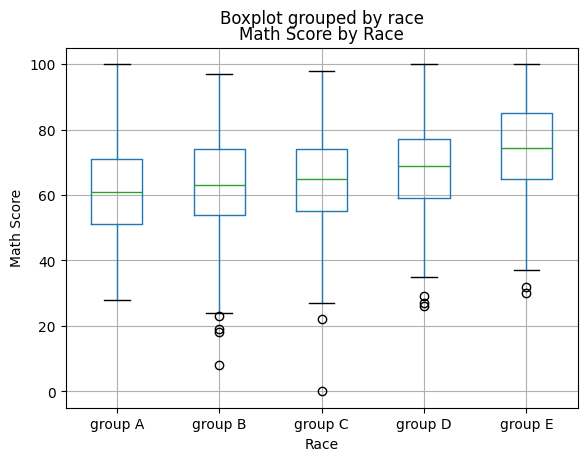

In [464]:
plt.figure()
df.boxplot(column="math_score", by="race")
plt.title("Math Score by Race")
plt.xlabel("Race")
plt.ylabel("Math Score")
plt.show()

This box plot suggests that math performance varies significantly across racial/ethnic groups. The significant differences are  driven by Groups D and E outperforming Groups A and B. The boxplot above also confirms this. Groups D and E show higher medians and the distribution of scores shifts upward compared to Groups A and B.

This finding suggests that significant performance gaps in math exam scores do exist across racial/ethnic groups in this dataset. More analysis would be necessary in order to analyze exactly what affects this gap. It could be socioeconomic factors, access to education resources in different regions, etc. 


Now, lets' move onto question 2 of our dataset analysis.

##### **Question 2: Does completing a test prep course improve math scores?**

Test preparation courses have een commonly used to help improve student exam performance. We want to see if this dataset also reflects this assumption. 

The way we analyzed this question was by using Independent Samples t-test. This is because we are comparing the means of a continuous variable (math score) between exactly two groups, students who completed test prep vs. those who did not. A student can only be in one group.

- **H₀ (Null):** There is no difference in mean math scores between students who completed test prep and those who did not.
- **Hₐ (Alternative):** Students who completed test prep have higher mean math scores.
- **Significance level:** α = 0.05





In [465]:
from scipy.stats import ttest_ind

# First seperate the non test prep and test prep students 
completed = df[df['test_prep_status'] == 'completed']['math_score']
none= df[df['test_prep_status'] == 'none']['math_score']

# T-test
stat, p=ttest_ind(completed, none)

print('p-value:', p)

if p< 0.05: 
    print("Reject null hypothesis: Test prep does affect math scores")
else: 
    print('fail to reject null hypothesis')

p-value: 1.5359134607147448e-08
Reject null hypothesis: Test prep does affect math scores


Given that the p-value was 1.53e-08, we **reject the null hypothesis**, meaning that test prep does in fact affect math scores.

Here's a boxplot to show the visualization of the binary comparison. 

/var/folders/t9/l9t3k75x6ql2n7syxl42t2kh0000gn/T/ipykernel_4814/3494032876.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='test_prep_status', y='math_score', palette='coolwarm')


Text(0, 0.5, 'Math score')

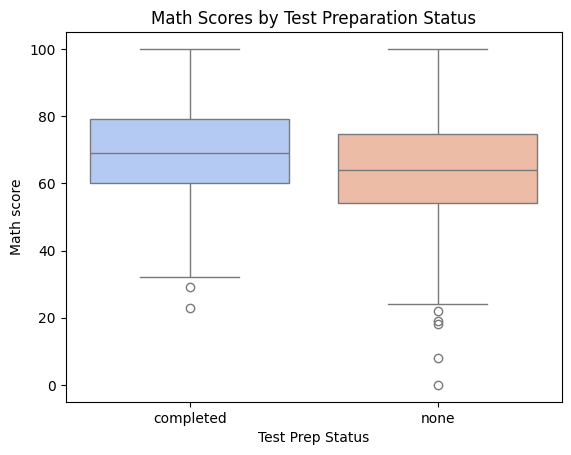

In [466]:
sns.boxplot(data=df, x='test_prep_status', y='math_score', palette='coolwarm')
plt.title("Math Scores by Test Preparation Status")
plt.xlabel("Test Prep Status")
plt.ylabel('Math score')

Here, you can clearly see that the math scores median and interquartile range is higher for those that have completed the test preparation course versus those who have not. This will be seen later on in our analysis, too, when we later examine feature importance in our machine learning models, where `test_prep_status` plays a large role in the exam scores for multiple subjects.

Now, let's move onto our last question of our analysis.

##### **Question #3: Does parental level of education have an effect on student lunch plan?**

Lunch plan type (standard vs. free/reduced) can sometimes give insight on a families socioeconomic status. We aim to test if thee is a true relationship between these variables. 

For this analysis, we use a Chi-Squared Test of Independence. This test is most effective in use because both of these factors we are assessing are categorical, not continuous numerical values. We also are trying to understand if these factors are independent or not from each other. 

- **H₀ (Null):** Parental level of education has no effect on a student's lunch plan (the two variables are independent).
- **Hₐ (Alternative):** Parental level of education is associated with a student's lunch plan.
- **Significance level:** α = 0.05


In [467]:
from scipy.stats import chi2_contingency

# Hypothesis testing: Chi-squared test
contingency_table = pd.crosstab(df["parental_level_of_education"], df["lunch_plan"])
stat, p, dof, expected = chi2_contingency(contingency_table)
print(f"P-value: {p}")

P-value: 0.9531014927218224


Using a significance value of 0.05, we find that the p-value is  0.953, which is greater than 0.05. This therefore means that the data is not significant and we accept the null hypothesis. Parental level of education has no effect on student lunch plan. Let's see if the visualization helps us understand the relationship between these factors more clearly.

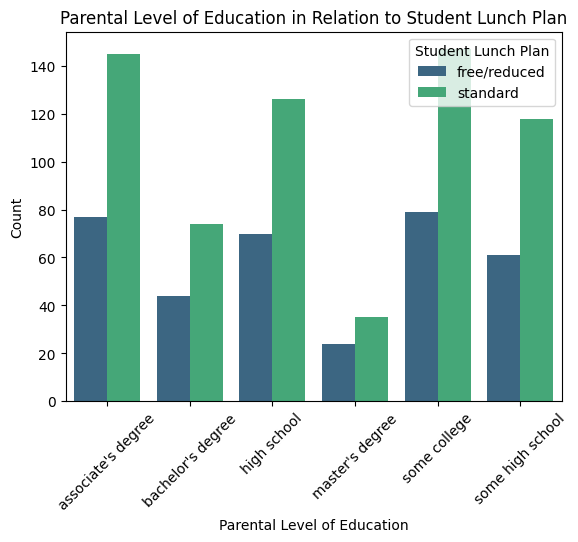

In [468]:
# Plotting relationship between parental level of education and lunch plan
sns.countplot(data = df, x = "parental_level_of_education", hue = "lunch_plan", palette = "viridis")
plt.xticks(rotation = 45)
plt.xlabel("Parental Level of Education")
plt.ylabel("Count")
plt.title("Parental Level of Education in Relation to Student Lunch Plan")
plt.legend(title = "Student Lunch Plan")

The histogram above supports the failure to reject the null hypothesis. There is no clear trendline or pattern that shows any relationship between lunhc plan type and parental education. The proportion of students on each lunch plan type appears pretty consistent across all parental education levels.


##### Summary of EDA Findings
Across our three hypothesis tests, we can draw the following takeaways: race/ethnicity does affect math exam performance, tes prep improves math exam performance, and parental education has no effect on lunch plan. 

This information gives us a better understanding of which variables/factors affect each other. Now, moving onto the machine learning section, we aim to analyze how mutliple of these variables/factord affect and relate to each other at the same time. 




### 4. Primary Analysis using Machine Learning Algorithm

During this analysis, we aim to analyze a few questions:
- Can we predict student performance from demographic/educational features?
- Which factors most influence scores?
- Are relationships linear or more complex?
- Which ML methods answer them?
    - Regression → prediction + relationships
    - Random Forest → feature importance + nonlinear structure check
    - What did you learn from them?
        - NOT “which model is better,” but:
            - predictability
            - feature influence
            - relationship structure

To answer our research questions about how demographic, educational, and socioeconomic factors influence student performance, we use a supervised machine learning regression approach.

Regression is appropriate because our main outcome variables—math, reading, and writing scores—are continuous numerical values. While our earlier statistical tests (ANOVA, t-test, chi-square) helped identify relationships between individual variables, they do not capture how multiple factors interact simultaneously to influence performance.

By using regression models, we can:

Predict student scores based on multiple features at once
Quantify the relative importance of each factor (e.g., test prep, parental education)
Capture combined effects that simpler hypothesis tests cannot
We begin with Linear Regression as a baseline due to its interpretability, allowing us to understand how each variable contributes to student outcomes. We then extend the analysis using a Random Forest Regressor, which can model nonlinear relationships and interactions between variables, potentially improving predictive performance.

This approach allows us to move from isolated statistical comparisons to a more comprehensive, predictive understanding of student performance.

##### 1. Imports 

In [469]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score
     

This step imports all necessary libraries.

pandas and numpy are used for data manipulation sklearn provides tools for preprocessing, building models, and evaluating performance We import both Linear Regression and Random Forest to compare models. 

Now, lets, also load the cleaned data with the standardized column names (lowercase + underscores) for easier coding and renamed columns to make them clearer and more consistent.

##### 2. Load the cleaned data  

In [470]:

df = pd.read_csv("../data/StudentsPerformance.csv")

# Clean column names
df.columns = df.columns.str.lower().str.replace(" ", "_")

df = df.rename(columns={
    "race/ethnicity": "race",
    "lunch": "lunch_plan",
    "test_preparation_course": "test_prep_status"
})

Now, let's plot the linear regression plot to see how each exam score subject relate to each other. 

##### 3. Linear regression plot exploration

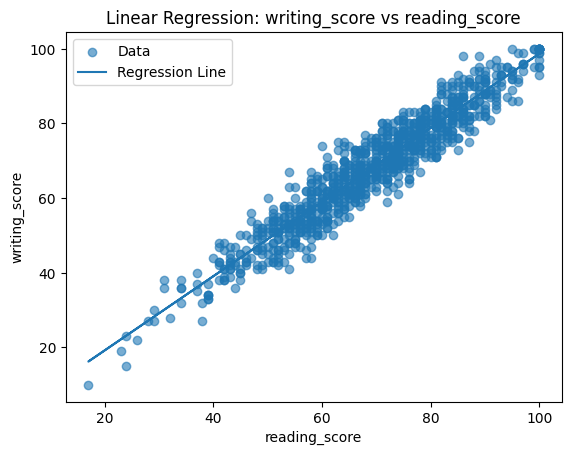

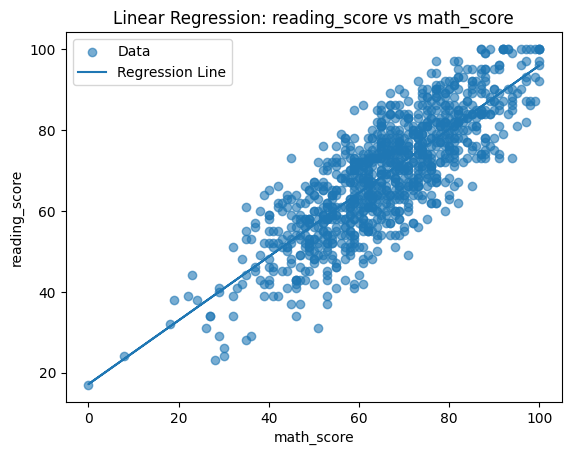

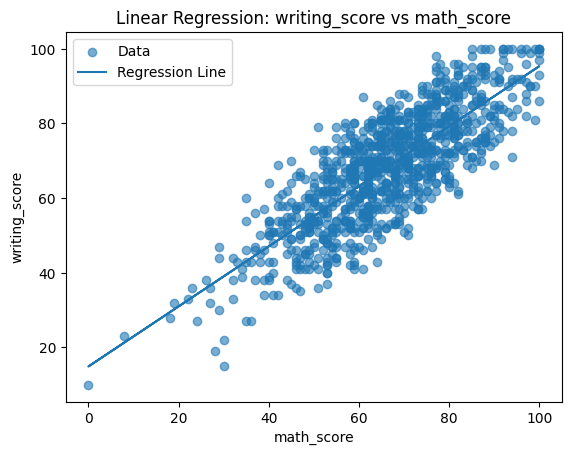

In [471]:
def plot_linear_regression(df, x_col, y_col):
    X = df[[x_col]].values
    y = df[y_col].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    plt.figure()
    plt.scatter(X, y, alpha=0.6, label="Data")
    plt.plot(X, y_pred, label="Regression Line")

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Linear Regression: {y_col} vs {x_col}")
    plt.legend()
    plt.show()

plot_linear_regression(df, "reading_score", "writing_score")
plot_linear_regression(df, "math_score", "reading_score")
plot_linear_regression(df, "math_score", "writing_score")

These graphs show a clear dependence on one another. These three regression plots collectively show strong positive relationships among reading, writing, and math scores.

**1. Reading Score vs Writing Score:**
- This relationship is the strongest, with data points clustering tightly around the regression line, indicating that students with higher reading scores almost always achieve higher writing scores.

**2. Math Score vs Reading Score:**
- This plot also demonstrates a clear positive trend, though with slightly more scatter, suggesting that math performance moderately predicts reading ability.

**3. Writing Score vs Math Score:**
This relationship is positive as well but appears to be the weakest of the three, reflecting greater variability and fewer overlapping skills between these domains.

Overall, the graphs indicate that students who perform well in one academic area tend to perform well in others, with the strength of the association depending on how closely the underlying skills are related.

Now, we can formally evaluate how well these variables can predict one another.

**4. Run linear regression and random forest models**

The run_models function is used here to train, evaluate, and model both linear regression and random forest machine learning strategies on a selected target variable. It removes the score columns, leaving only demographic and categorical variables as predictors, with the chosen target score being the target.

Additionally, the data is split into training and test sets to avoid bias. Each model is trained on the training data and used to predict the target variable. The function will return a set of test values, predictions, and metrics such as R² and RMSE to assess how well each model is predicting the target outcome.

In [472]:
def run_models(df, target_column):

    X = df.drop(columns=["math_score", "reading_score", "writing_score"])
    y = df[target_column]

    categorical_features = X.select_dtypes(include=["object"]).columns

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(drop="first"), categorical_features)
        ],
        remainder="passthrough"
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Linear Regression
    lr_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ])

    lr_pipeline.fit(X_train, y_train)
    y_pred_lr = lr_pipeline.predict(X_test)

    # Random Forest
    rf_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=100, random_state=42))
    ])

    rf_pipeline.fit(X_train, y_train)
    y_pred_rf = rf_pipeline.predict(X_test)

    return {
        "target": target_column,
        "y_test": y_test,
        "y_pred_lr": y_pred_lr,
        "y_pred_rf": y_pred_rf,
        "lr_r2": r2_score(y_test, y_pred_lr),
        "lr_rmse": np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        "rf_r2": r2_score(y_test, y_pred_rf),
        "rf_rmse": np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        "rf_pipeline": rf_pipeline
    }

##### 5. Display the results for each testing variable


In [473]:
math_results = run_models(df, "math_score")
reading_results = run_models(df, "reading_score")
writing_results = run_models(df, "writing_score")

def print_results(results):
    print(f"\nResults for {results['target']}:")
    print("Linear Regression -> R2:", results["lr_r2"],
          "| RMSE:", results["lr_rmse"])
    print("Random Forest     -> R2:", results["rf_r2"],
          "| RMSE:", results["rf_rmse"])

print_results(math_results)
print_results(reading_results)
print_results(writing_results)

/var/folders/t9/l9t3k75x6ql2n7syxl42t2kh0000gn/T/ipykernel_4814/2428664011.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns
/var/folders/t9/l9t3k75x6ql2n7syxl42t2kh0000gn/T/ipykernel_4814/2428664011.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See ht


Results for math_score:
Linear Regression -> R2: 0.17599998338251166 | RMSE: 14.160185226319358
Random Forest     -> R2: -0.016971737308242307 | RMSE: 15.731124416322185

Results for reading_score:
Linear Regression -> R2: 0.15939617857969446 | RMSE: 13.79186391872779
Random Forest     -> R2: -0.018860136967894015 | RMSE: 15.183943140903628

Results for writing_score:
Linear Regression -> R2: 0.2637358790675757 | RMSE: 13.321116741030652
Random Forest     -> R2: 0.1073505982412779 | RMSE: 14.667776196392106


/var/folders/t9/l9t3k75x6ql2n7syxl42t2kh0000gn/T/ipykernel_4814/2428664011.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


Across all targets, the models demonstrated limited predictive power, with linear regression explaining only 16 to 26% of the variance and random forest models performing similarly or worse.

These results indicate that the available demographic features carry only weak predictive signal and are insufficient for accurately estimating student performance on their own.

Notably, writing score was the most predictable outcome, while math and reading scores showed even lower explainability. Overall, the machine learning analysis suggests that background characteristics alone do not strongly determine academic achievement.

Pertaining to our research questions, additional behavioral or instructional variables would be needed for more accurate prediction, which is limited by the dataset.

The models may not have blown us away, but they did give us something to work with. Let’s take a look at how their predictions stack up against the actual outcomes!

##### 6. Predicted vs. Actual Results


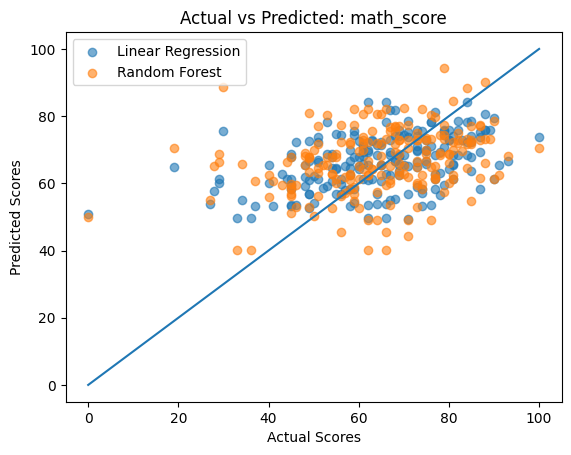

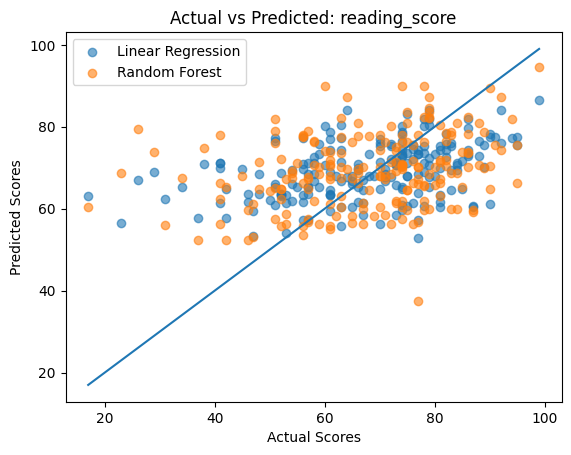

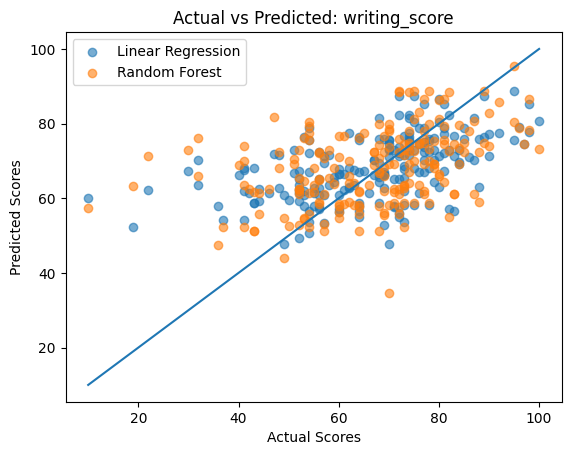

In [474]:
def plot_predictions(results):
    plt.figure()

    plt.scatter(results["y_test"], results["y_pred_lr"], alpha=0.6, label="Linear Regression")
    plt.scatter(results["y_test"], results["y_pred_rf"], alpha=0.6, label="Random Forest")

    min_val = min(results["y_test"])
    max_val = max(results["y_test"])

    plt.plot([min_val, max_val], [min_val, max_val])

    plt.xlabel("Actual Scores")
    plt.ylabel("Predicted Scores")
    plt.title(f"Actual vs Predicted: {results['target']}")
    plt.legend()
    plt.show()

plot_predictions(math_results)
plot_predictions(reading_results)
plot_predictions(writing_results)

Across all three subjects the predicted vs. actual plots show the same overall pattern: both models produce predictions that loosely follow the diagonal “perfect prediction” line, but with substantial scatter. This visual spread confirms what the performance metrics already suggested: the models capture only a small portion of the true variation in scores.

The Linear Regression points tend to cluster a bit closer to the diagonal than the Random Forest points, which aligns with its consistently higher R² values. Meanwhile, the Random Forest predictions show wider dispersion and more deviation from the ideal line, reflecting its tendency to overfit the training data and generalize poorly on the test set.

Among the three outcomes, writing scores show the tightest clustering, indicating that writing is the most predictable target in this dataset, while math and reading predictions appear more widely scattered.

Overall, these plots reinforce the conclusion that the demographic, behavioral, and socioeconomica features in this dataset alone provide only limited predictive power, and that both models struggle to produce highly accurate score estimates.

While overall predictive performance provides insight into how well each model captures student performance, it does not explain which variables are driving those predictions. To address this, a feature importance analysis was performed using the Random Forest model. This allows us to identify which student attributes contribute most strongly to predicting exam scores, even when overall model accuracy is limited.

**8. Determine feature importance through ranking**

/var/folders/t9/l9t3k75x6ql2n7syxl42t2kh0000gn/T/ipykernel_4814/1672937811.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


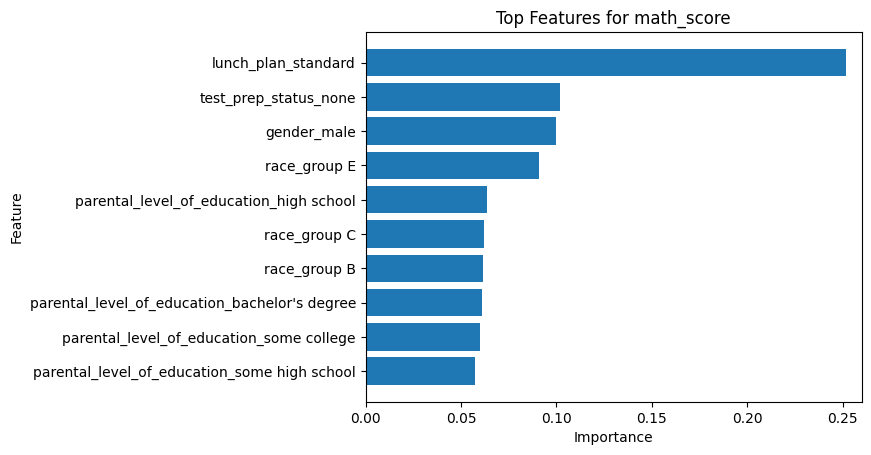

/var/folders/t9/l9t3k75x6ql2n7syxl42t2kh0000gn/T/ipykernel_4814/1672937811.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


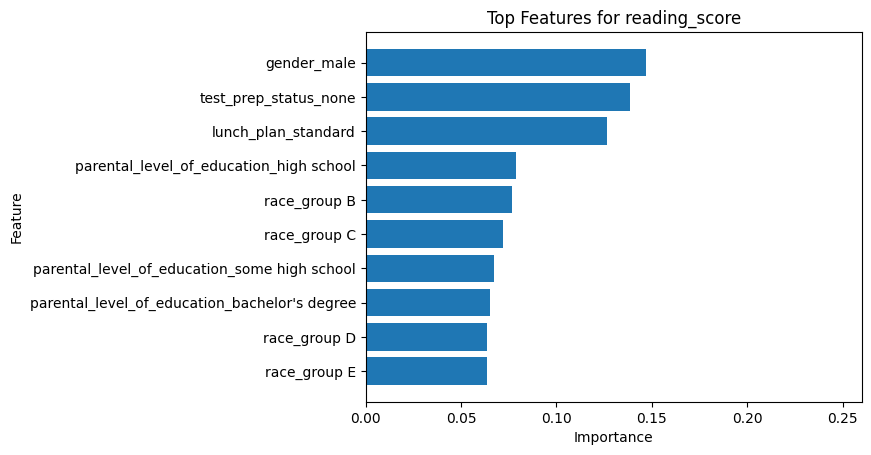

/var/folders/t9/l9t3k75x6ql2n7syxl42t2kh0000gn/T/ipykernel_4814/1672937811.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


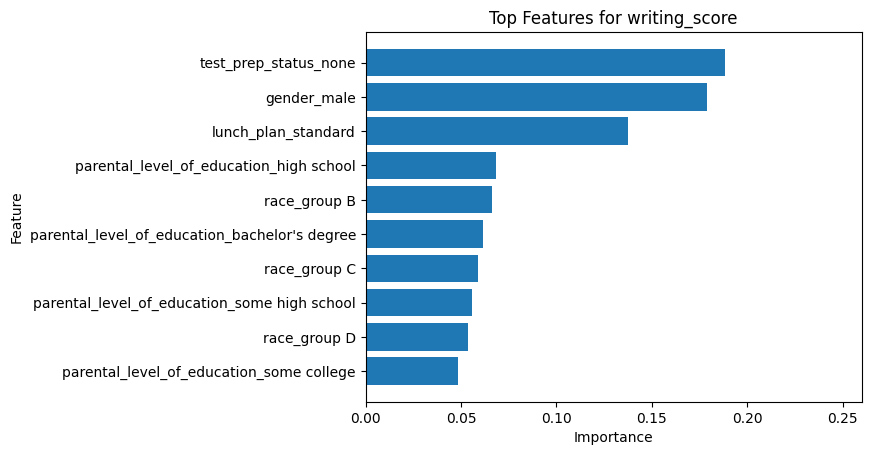

In [475]:
def plot_feature_importance(results, df):

    rf_pipeline = results["rf_pipeline"]

    X = df.drop(columns=["math_score", "reading_score", "writing_score"])
    categorical_features = X.select_dtypes(include=["object"]).columns

    encoded_features = rf_pipeline.named_steps["preprocessor"] \
        .transformers_[0][1] \
        .get_feature_names_out(categorical_features)

    importances = rf_pipeline.named_steps["model"].feature_importances_

    importance_df = pd.DataFrame({
        "feature": encoded_features,
        "importance": importances
    }).sort_values(by="importance", ascending=False).head(10)


    plt.figure()
    plt.barh(importance_df["feature"], importance_df["importance"])
    plt.xlabel("Importance")
    plt.xlim(0, 0.26)   # ← set a fixed scale for all plots
    plt.ylabel("Feature")
    plt.title(f"Top Features for {results['target']}")
    plt.gca().invert_yaxis()
    plt.show()

plot_feature_importance(math_results, df)
plot_feature_importance(reading_results, df)
plot_feature_importance(writing_results, df)

### 5. Insights and Conclusion 
Returning back to our original research questions, we set out to explore whether or not we could predict student performance from demographic/educational features, and which specific factors most influence scores. In part 3 of the analysis where we explored data through linear regression, we saw that there was a strong positive relationship between performance on different exams, where students who obtained high scores in one exam also typically performed well on other exams. This suggests that students who perform well in one subject also tend to perform well across multiple subjects. This may be explained by factors such as study habits, or other demographic/educational features, which we sought to explore through feature importance exploration in part 8 of the analysis.

Using the plot_feature_importance function, we plotted the importance of a multitude of features for each of the subject exam scores. For the math score, there was a clear leader in importance: lunch_plan_standard. lunch_plan_standard is a variable indicating that a student follows the standard full-price lunch plan, as opposed to a free/reduced lunch plan. As free/reduced lunch plans are typically offered to lower socioeconomic families, this finding suggests that socioeconomic status may have a meaningful influence on math exam scores. This standard lunch plan variable also seems to be quite important among the other subject exam scores (reading and writing), consistently placing within the top 3 most important variables within the dataset.

Interestingly, the male gender variable also placed consistently high, within the top three most influential variables for all of the subjects. This may suggest differences in performance patterns or study habits associated with gender, although further research may be required to better understand the underlying causes. The test_prep_status_none variable also placed high among importance for all three subjects. However, this result is more intuitive since increased or decreased study time in general typically influences how well students perform on exams.

Race and parental levels of education through different stages of schooling appeared to be similarly important, but significantly less so than gender, lunch plan, and test prep statuses.

Overall, there seems to be a strong correlation between the previously mentioned variables and exam scores, indicating that we can predict student performance from some demographic/educational features to a certain extent, and the analysis was able to identify several influential factors on exam scores. However, further analysis and additional research beyond machine learning analysis may be beneficial to gauge why and how exactly these specific factors are most influential on exam scores.

Reading through the project, an uninformed reader would undoubtebly feel informed about the topic, especially given the conclusions provided above. A reader who already knew about the topic would also feel like they learned more about it, most notably with the surprising fact that gender is influential on exam scores.